# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [15]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

In [4]:
print(fraud["fraud"].value_counts())

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


In [5]:
print(fraud["fraud"].value_counts(normalize=True))

fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64


Yes as the destribution is 91% and 8%,the dataset is really imbalanced

In [7]:
# Features and target
X = fraud.drop(columns=["fraud"])
y = fraud["fraud"]

In [8]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# =========================
# BASELINE MODEL
# =========================

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

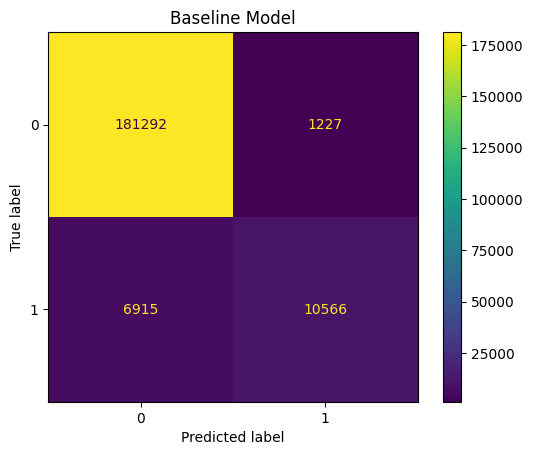

In [16]:
# Baseline confusion matrix
cm = confusion_matrix(y_test, baseline_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Baseline Model")
plt.show()

In [22]:
# =========================
# RANDOM OVERSAMPLING
# =========================

train_df = X_train.copy()

train_df["fraud"] = y_train

# Separate classes
fraud_positive = train_df[train_df["fraud"] == 1]
fraud_negative = train_df[train_df["fraud"] == 0]

In [23]:
# Oversample minority class
fraud_positive_oversampled = resample(
    fraud_positive,
    replace=True,
    n_samples=len(fraud_negative),
    random_state=42
)

In [24]:
# Combine data
fraud_over = pd.concat([
    fraud_negative,
    fraud_positive_oversampled
])

In [25]:
# Check new balance
print(fraud_over["fraud"].value_counts())

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


In [26]:
# Split oversampled features and target
X_train_over = fraud_over.drop(columns=["fraud"])
y_train_over = fraud_over["fraud"]

In [27]:
# Train model with oversampled data
oversampled_model = LogisticRegression(max_iter=1000)

oversampled_model.fit(X_train_over, y_train_over)

oversampled_pred = oversampled_model.predict(X_test)

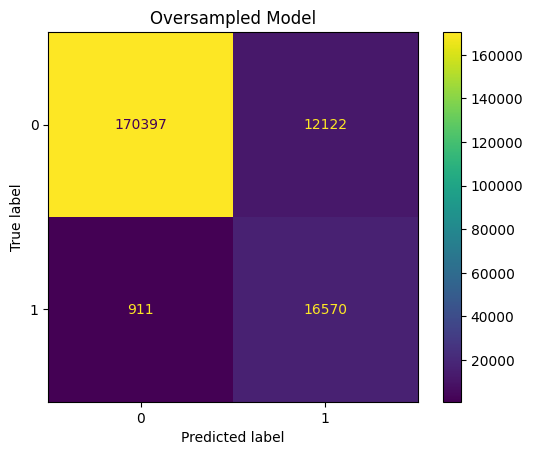

In [28]:
# Oversampled confusion matrix
cm = confusion_matrix(y_test, oversampled_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Oversampled Model")
plt.show()

In [30]:
# =========================
# RANDOM UNDERSAMPLING
# =========================

fraud_negative_undersampled = resample(
    fraud_negative,
    replace=False,
    n_samples=len(fraud_positive),
    random_state=42
)

fraud_under = pd.concat([
    fraud_negative_undersampled,
    fraud_positive
])

print(fraud_under["fraud"].value_counts())

fraud
0.0    69922
1.0    69922
Name: count, dtype: int64


In [31]:
# Split undersampled features and target
X_train_under = fraud_under.drop(columns=["fraud"])
y_train_under = fraud_under["fraud"]

In [32]:
# Train model with undersampled data
undersampled_model = LogisticRegression(max_iter=1000)

undersampled_model.fit(X_train_under, y_train_under)

undersampled_pred = undersampled_model.predict(X_test)

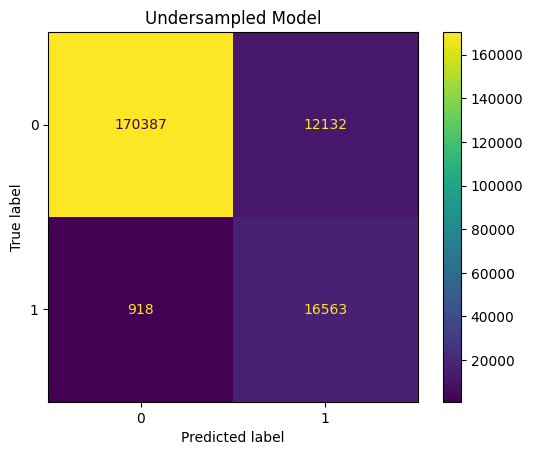

In [33]:
# Undersampled confusion matrix
cm = confusion_matrix(y_test, undersampled_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Undersampled Model")
plt.show()

In [34]:
# =========================
# SMOTE
# =========================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

print(pd.Series(y_smote).value_counts())

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


In [35]:
# Train model with undersampled data
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_smote, y_smote)

smote_pred = smote_model.predict(X_test)

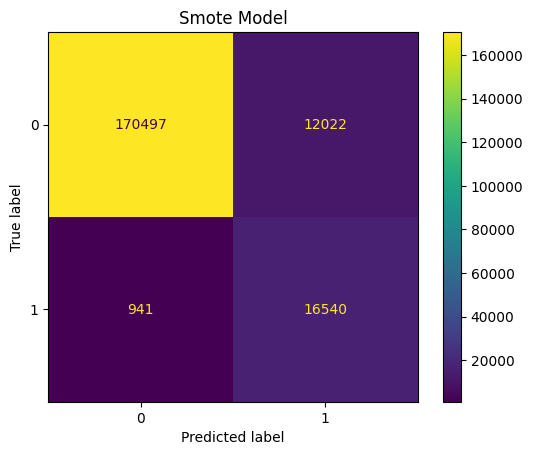

In [36]:
# Undersampled confusion matrix
cm = confusion_matrix(y_test, smote_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Smote Model")
plt.show()

here all the 3 methods oversampling, undersampling and smote giving alomost same results in TP and TN.